# EWL Ablation Analysis
**FGVC-Aircraft** · LoRA ViT-Base

Compares EWL vs SFT baseline across:
- **Rank** ablation (r = 2, 4, 8, 16)
- **Temperature** ablation (τ = 1.0 – 3.0)
- **Alpha** ablation (α = 0.5 – 1.0)

All figures show **mean ± 1 std** across seeds {11, 22, 33}.

In [1]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 1200,
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "legend.framealpha": 0.9,
    "legend.fontsize": 9,
})

# NeurIPS-style palette: muted, print-safe, colourblind-friendly
C = {
    "ewl": "#2166AC",   # steel blue  — model of interest
    "sft": "#D6604D",   # muted red   — baseline
}
ALPHA_FILL = 0.15  # shading transparency

## 1. Load results

In [2]:
RESULTS_DIR = Path("../outputs/vision/aircraft_ablations")
SEEDS = [11, 22, 33]   # set to None to load all seeds

# ── directory name parsers ────────────────────────────────────────────────────
_EWL_RE  = re.compile(r"^r(\d+)_a([\d.]+)_t([\d.]+)_s(\d+)$")
_SFT_RE  = re.compile(r"^baseline_r(\d+)_s(\d+)$")

def _parse_dir(d: Path):
    """Return a metadata dict from a run directory name, or None if unrecognised."""
    name = d.name
    m = _EWL_RE.match(name)
    if m:
        return dict(condition="ewl",
                    rank=int(m[1]), alpha=float(m[2]),
                    temperature=float(m[3]), seed=int(m[4]))
    m = _SFT_RE.match(name)
    if m:
        return dict(condition="sft",
                    rank=int(m[1]), alpha=None,
                    temperature=None, seed=int(m[2]))
    return None

def load_runs(base: Path = RESULTS_DIR, seeds=SEEDS) -> pd.DataFrame:
    """
    Scan *base* for run directories, load the latest results_*.json in each,
    and return a tidy DataFrame with one row per run.

    seeds: list of ints to include, or None to load all seeds.

    Columns: condition, rank, alpha, temperature, seed,
             test_acc, test_f1, test_loss, history (list of dicts)
    """
    rows = []
    for d in sorted(base.iterdir()):
        if not d.is_dir():
            continue
        meta = _parse_dir(d)
        if meta is None:
            continue
        if seeds is not None and meta["seed"] not in seeds:
            continue
        jsons = sorted(d.glob("results_*.json"))
        if not jsons:
            continue
        with open(jsons[-1]) as f:   # latest by timestamp in filename
            payload = json.load(f)
        meta.update({
            "test_acc":  payload.get("test_acc"),
            "test_f1":   payload.get("test_f1"),
            "test_loss": payload.get("test_loss"),
            "history":   payload.get("history", []),
        })
        rows.append(meta)
    df = pd.DataFrame(rows)
    seed_str = str(seeds) if seeds else "all"
    print(f"Loaded {len(df)} runs  "
          f"({(df.condition=='ewl').sum()} EWL, {(df.condition=='sft').sum()} SFT)  "
          f"seeds={seed_str}")
    return df

df = load_runs()
df.drop(columns="history").sort_values(["condition","rank","alpha","temperature","seed"])

Loaded 54 runs  (42 EWL, 12 SFT)  seeds=[11, 22, 33]


,condition,rank,alpha,temperature,seed,test_acc,test_f1,test_loss
15,ewl,2,0.9,1.0,11,0.576058,0.575927,1.624976
16,ewl,2,0.9,1.0,22,0.574257,0.574583,1.633489
17,ewl,2,0.9,1.0,33,0.571557,0.572034,1.613651
18,ewl,4,0.5,1.0,11,0.576058,0.576025,1.580968
19,ewl,4,0.5,1.0,22,0.584758,0.586834,1.569429
20,ewl,4,0.5,1.0,33,0.584458,0.585031,1.546419
21,ewl,4,0.6,1.0,11,0.574557,0.574517,1.579367
22,ewl,4,0.6,1.0,22,0.583258,0.585133,1.562674
23,ewl,4,0.6,1.0,33,0.587459,0.588228,1.540849
24,ewl,4,0.7,1.0,11,0.570057,0.569905,1.574375


In [3]:
def get_curves(subset, metric="val_acc"):
    """Stack per-epoch metric from all runs. Returns (epochs, mean, std)."""
    series = []
    for _, row in subset.iterrows():
        vals = [ep[metric] for ep in row["history"] if ep.get(metric) is not None]
        series.append(vals)
    if not series:
        return [], [], []
    min_len = min(len(s) for s in series)
    arr = np.array([s[:min_len] for s in series])
    return np.arange(1, min_len + 1), arr.mean(0), arr.std(0)


def plot_curves(ax, subset_ewl, subset_sft, metric="val_acc",
                label_ewl="EWL", label_sft="SFT baseline"):
    """Plot mean ± std shaded curves for two subsets."""
    for subset, label, color in [
        (subset_ewl, label_ewl, C["ewl"]),
        (subset_sft, label_sft, C["sft"]),
    ]:
        ep, mu, sigma = get_curves(subset, metric)
        if len(ep) == 0:
            continue
        ax.plot(ep, mu, color=color, lw=2, label=label)
        ax.fill_between(ep, mu - sigma, mu + sigma, color=color, alpha=ALPHA_FILL)


def bar_with_err(ax, xs, ys_ewl, errs_ewl, ys_sft, errs_sft,
                 x_labels, xlabel, ylabel, title):
    """Grouped bar chart: EWL (left) vs SFT (right) per x-value."""
    xs_idx = np.arange(len(xs))
    w = 0.35
    bars_ewl = ax.bar(xs_idx - w/2, ys_ewl, w, yerr=errs_ewl,
                      color=C["ewl"], capsize=4, label="EWL", alpha=0.85)
    bars_sft = ax.bar(xs_idx + w/2, ys_sft, w, yerr=errs_sft,
                      color=C["sft"], capsize=4, label="SFT", alpha=0.85)
    ax.set_xticks(xs_idx)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    for bars, errs in [(bars_ewl, errs_ewl), (bars_sft, errs_sft)]:
        for bar, err in zip(bars, errs):
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + err + 0.002,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=8)

print("Helpers defined.")

Helpers defined.


## Figure 1 — EWL vs SFT: Learning curves (best config)
Fixed config: rank=4, α=0.9, τ=2.0 · averaged over seeds {11, 22, 33}

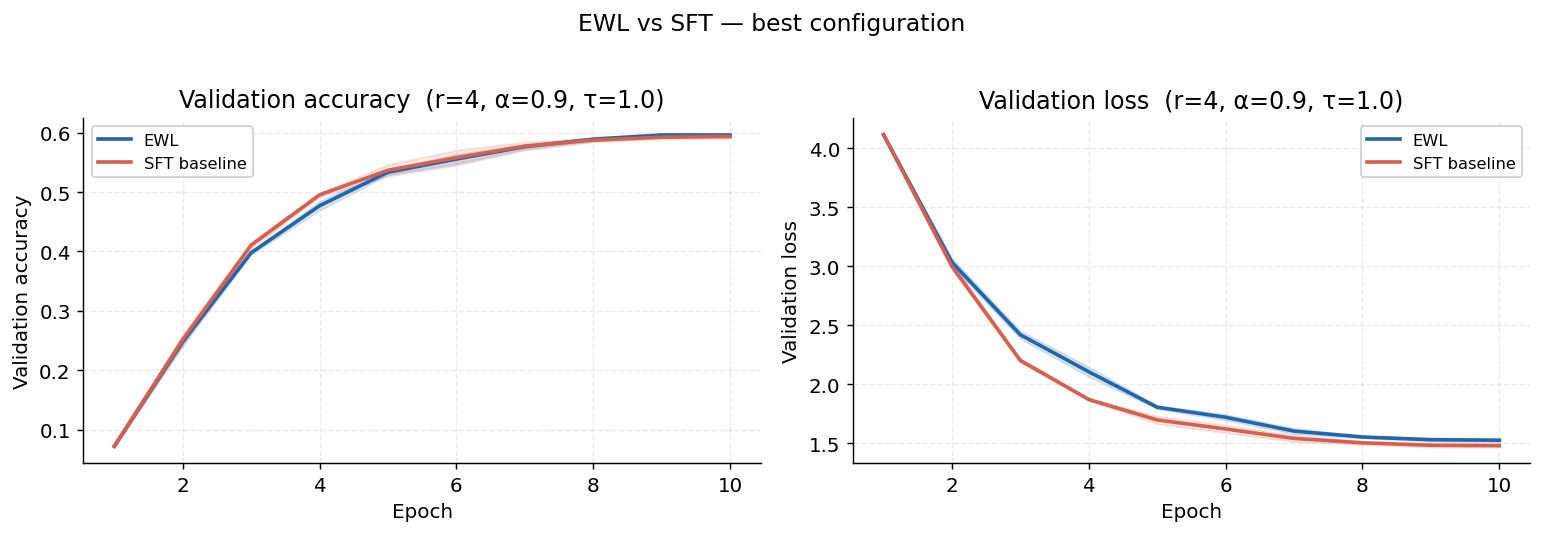

In [4]:
BEST_RANK, BEST_ALPHA, BEST_TEMP = 4, 0.9, 1.0

ewl_best = df[(df.condition == "ewl") &
              (df['rank'] == BEST_RANK) &
              (df.alpha == BEST_ALPHA) &
              (df.temperature == BEST_TEMP)]
sft_best = df[(df.condition == "sft") & (df['rank'] == BEST_RANK)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, ylabel in [
    (axes[0], "val_acc",  "Validation accuracy"),
    (axes[1], "val_loss", "Validation loss"),
]:
    plot_curves(ax, ewl_best, sft_best, metric=metric)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel}  (r={BEST_RANK}, α={BEST_ALPHA}, τ={BEST_TEMP})")
    ax.legend()

plt.suptitle("EWL vs SFT — best configuration", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Figure 2 — Rank ablation
Vary rank ∈ {2, 4, 8, 16} with fixed α=0.9, τ=2.0.
Left: final test accuracy · Right: learning curves per rank.

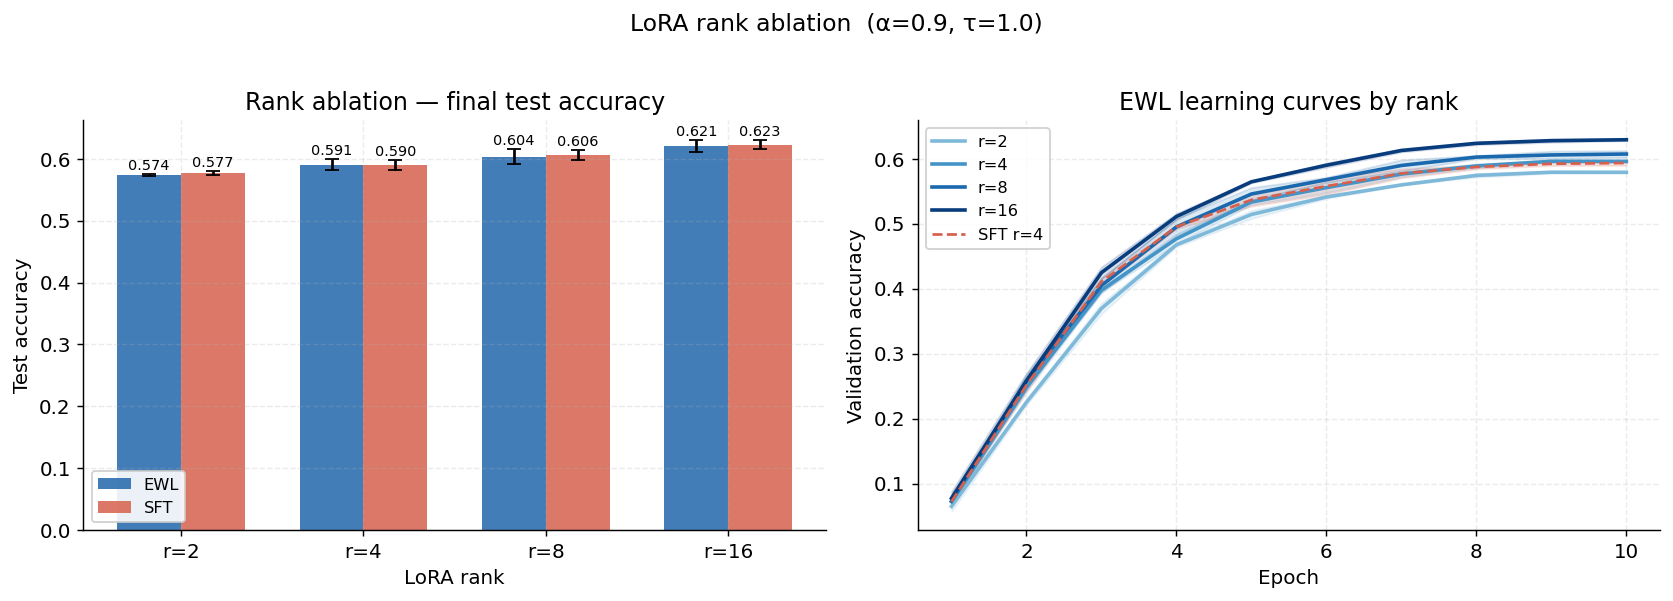

In [5]:
RANKS = [2, 4, 8, 16]

ys_ewl, errs_ewl = [], []
ys_sft, errs_sft = [], []

for r in RANKS:
    ewl_r = df[(df.condition == "ewl") & (df['rank'] == r) &
               (df.alpha == BEST_ALPHA) & (df.temperature == BEST_TEMP)]["test_acc"].dropna()
    sft_r = df[(df.condition == "sft") & (df['rank'] == r)]["test_acc"].dropna()
    ys_ewl.append(ewl_r.mean());  errs_ewl.append(ewl_r.std())
    ys_sft.append(sft_r.mean());  errs_sft.append(sft_r.std())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: grouped bar
bar_with_err(axes[0], RANKS, ys_ewl, errs_ewl, ys_sft, errs_sft,
             x_labels=[f"r={r}" for r in RANKS],
             xlabel="LoRA rank", ylabel="Test accuracy",
             title="Rank ablation — final test accuracy")

# Right: learning curves per rank (EWL only)
rank_colors = plt.cm.Blues(np.linspace(0.45, 0.95, len(RANKS)))
for r, col in zip(RANKS, rank_colors):
    sub = df[(df.condition == "ewl") & (df['rank'] == r) &
             (df.alpha == BEST_ALPHA) & (df.temperature == BEST_TEMP)]
    ep, mu, sigma = get_curves(sub, "val_acc")
    if len(ep) == 0:
        continue
    axes[1].plot(ep, mu, color=col, lw=2, label=f"r={r}")
    axes[1].fill_between(ep, mu - sigma, mu + sigma, color=col, alpha=ALPHA_FILL)

# Overlay SFT at best rank as reference
ep, mu, sigma = get_curves(sft_best, "val_acc")
if len(ep):
    axes[1].plot(ep, mu, color=C["sft"], lw=1.5, ls="--", label=f"SFT r={BEST_RANK}")
    axes[1].fill_between(ep, mu - sigma, mu + sigma, color=C["sft"], alpha=ALPHA_FILL)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("EWL learning curves by rank")
axes[1].legend()

plt.suptitle("LoRA rank ablation  (α=0.9, τ=1.0)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Figure 3 — Temperature ablation
Vary τ ∈ {1.0, 1.5, 2.0, 2.5, 3.0} with fixed rank=4, α=0.9.

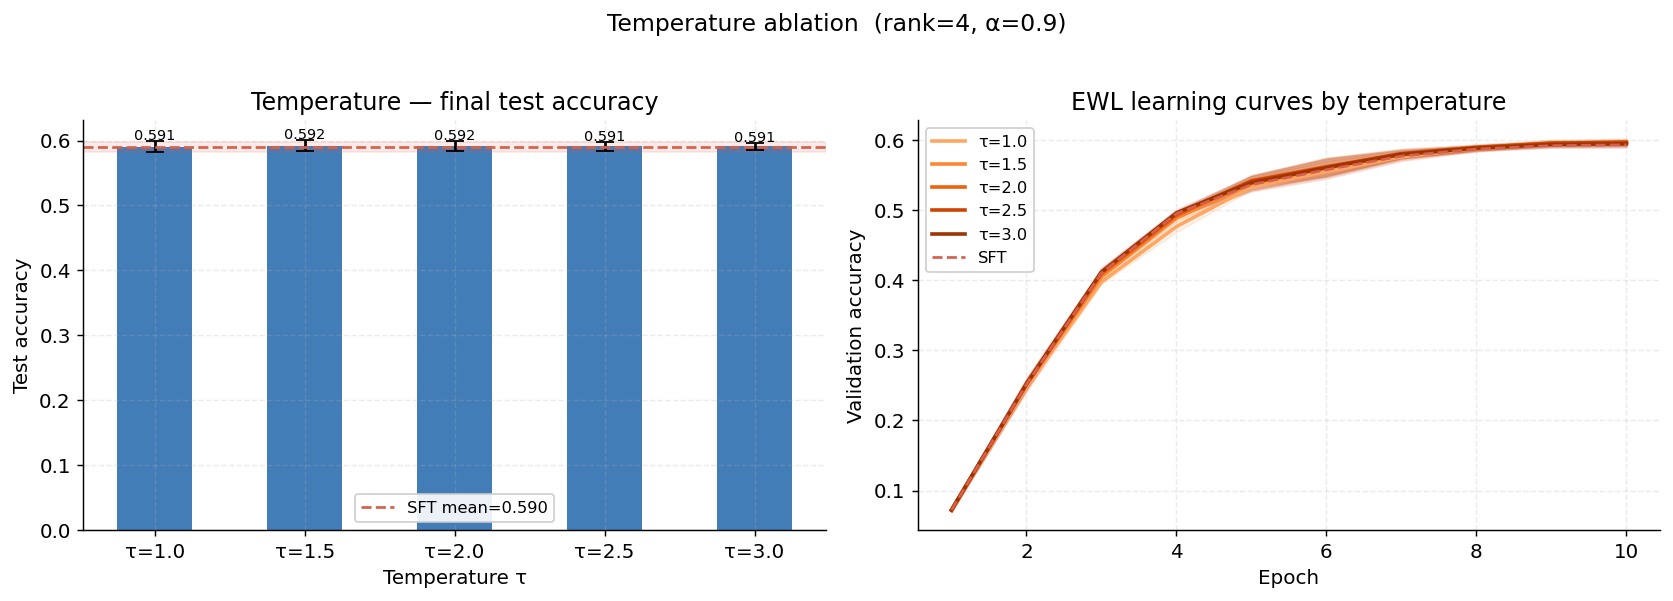

In [6]:
TEMPS = [1.0, 1.5, 2.0, 2.5, 3.0]

ys_t, errs_t = [], []
for t in TEMPS:
    sub = df[(df.condition == "ewl") & (df['rank'] == BEST_RANK) &
             (df.alpha == BEST_ALPHA) & (df.temperature == t)]["test_acc"].dropna()
    ys_t.append(sub.mean())
    errs_t.append(sub.std())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: bar chart
axes[0].bar(range(len(TEMPS)), ys_t, yerr=errs_t,
            color=C["ewl"], capsize=5, alpha=0.85, width=0.5)
# SFT reference line
sft_mu = df[(df.condition == "sft") & (df['rank'] == BEST_RANK)]["test_acc"].mean()
sft_std = df[(df.condition == "sft") & (df['rank'] == BEST_RANK)]["test_acc"].std()
axes[0].axhline(sft_mu, color=C["sft"], lw=1.5, ls="--", label=f"SFT mean={sft_mu:.3f}")
axes[0].axhspan(sft_mu - sft_std, sft_mu + sft_std, color=C["sft"], alpha=0.12)
for i, (y, e) in enumerate(zip(ys_t, errs_t)):
    axes[0].text(i, y + e + 0.002, f"{y:.3f}", ha="center", fontsize=8)
axes[0].set_xticks(range(len(TEMPS)))
axes[0].set_xticklabels([f"τ={t}" for t in TEMPS])
axes[0].set_xlabel("Temperature τ")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Temperature — final test accuracy")
axes[0].legend()

# Right: learning curves per temperature
temp_colors = plt.cm.Oranges(np.linspace(0.4, 0.9, len(TEMPS)))
for t, col in zip(TEMPS, temp_colors):
    sub = df[(df.condition == "ewl") & (df['rank'] == BEST_RANK) &
             (df.alpha == BEST_ALPHA) & (df.temperature == t)]
    ep, mu, sigma = get_curves(sub, "val_acc")
    if len(ep) == 0:
        continue
    axes[1].plot(ep, mu, color=col, lw=2, label=f"τ={t}")
    axes[1].fill_between(ep, mu - sigma, mu + sigma, color=col, alpha=ALPHA_FILL)

ep, mu, sigma = get_curves(sft_best, "val_acc")
if len(ep):
    axes[1].plot(ep, mu, color=C["sft"], lw=1.5, ls="--", label="SFT")
    axes[1].fill_between(ep, mu - sigma, mu + sigma, color=C["sft"], alpha=ALPHA_FILL)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("EWL learning curves by temperature")
axes[1].legend()

plt.suptitle("Temperature ablation  (rank=4, α=0.9)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Figure 4 — Alpha (EMA decay) ablation
Vary α ∈ {0.5, 0.6, 0.7, 0.8, 0.9, 1.0} with fixed rank=4, τ=2.0.

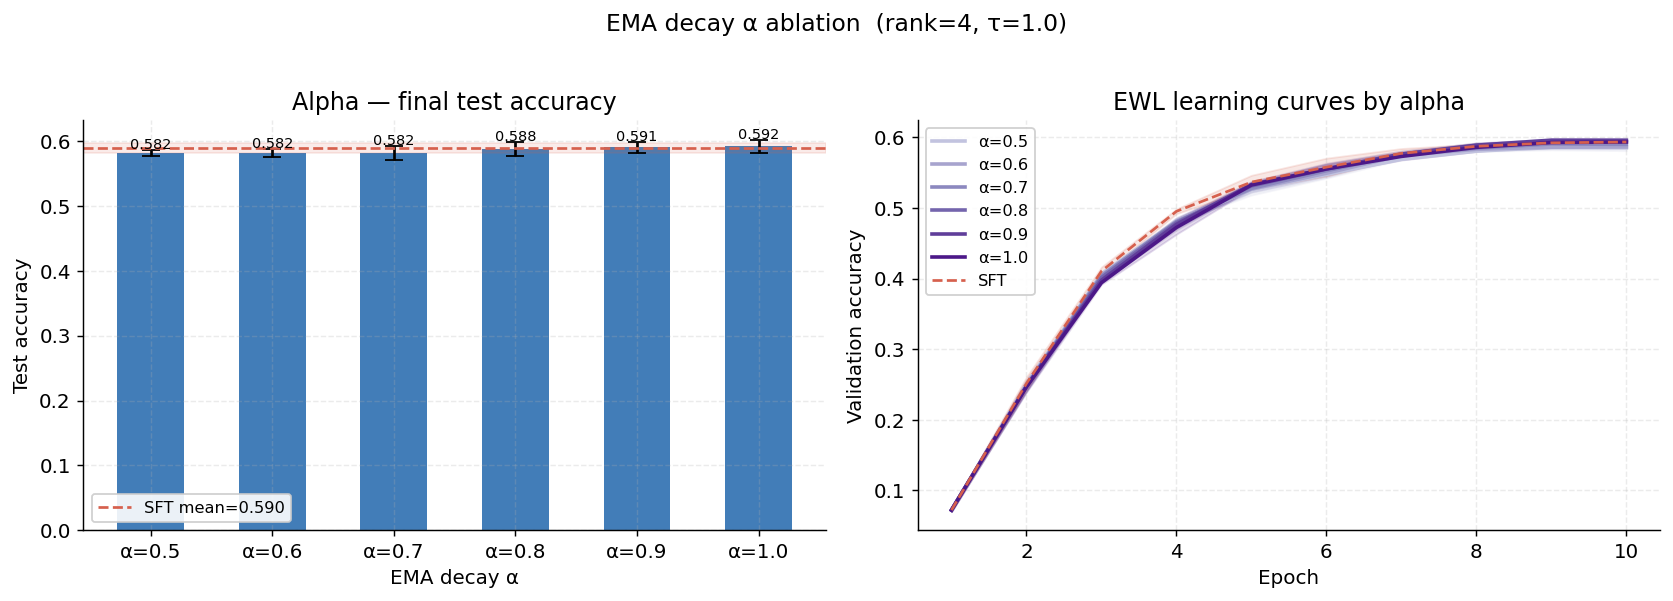

In [7]:
ALPHAS = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

ys_a, errs_a = [], []
for a in ALPHAS:
    sub = df[(df.condition == "ewl") & (df['rank'] == BEST_RANK) &
             (df.alpha == a) & (df.temperature == BEST_TEMP)]["test_acc"].dropna()
    ys_a.append(sub.mean())
    errs_a.append(sub.std())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: bar chart
axes[0].bar(range(len(ALPHAS)), ys_a, yerr=errs_a,
            color=C["ewl"], capsize=5, alpha=0.85, width=0.55)
axes[0].axhline(sft_mu, color=C["sft"], lw=1.5, ls="--", label=f"SFT mean={sft_mu:.3f}")
axes[0].axhspan(sft_mu - sft_std, sft_mu + sft_std, color=C["sft"], alpha=0.12)
for i, (y, e) in enumerate(zip(ys_a, errs_a)):
    axes[0].text(i, y + e + 0.002, f"{y:.3f}", ha="center", fontsize=8)
axes[0].set_xticks(range(len(ALPHAS)))
axes[0].set_xticklabels([f"α={a}" for a in ALPHAS])
axes[0].set_xlabel("EMA decay α")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Alpha — final test accuracy")
axes[0].legend()

# Right: learning curves per alpha
alpha_colors = plt.cm.Purples(np.linspace(0.35, 0.92, len(ALPHAS)))
for a, col in zip(ALPHAS, alpha_colors):
    sub = df[(df.condition == "ewl") & (df['rank'] == BEST_RANK) &
             (df.alpha == a) & (df.temperature == BEST_TEMP)]
    ep, mu, sigma = get_curves(sub, "val_acc")
    if len(ep) == 0:
        continue
    axes[1].plot(ep, mu, color=col, lw=2, label=f"α={a}")
    axes[1].fill_between(ep, mu - sigma, mu + sigma, color=col, alpha=ALPHA_FILL)

ep, mu, sigma = get_curves(sft_best, "val_acc")
if len(ep):
    axes[1].plot(ep, mu, color=C["sft"], lw=1.5, ls="--", label="SFT")
    axes[1].fill_between(ep, mu - sigma, mu + sigma, color=C["sft"], alpha=ALPHA_FILL)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("EWL learning curves by alpha")
axes[1].legend()

plt.suptitle("EMA decay α ablation  (rank=4, τ=1.0)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Figure 5 — Hyperparameter sensitivity summary
The sweep is a **cross**: alpha varies at fixed τ=2.0, temperature varies at fixed α=0.9.
Both are shown normalised to [0,1] so sensitivity magnitude is directly comparable.

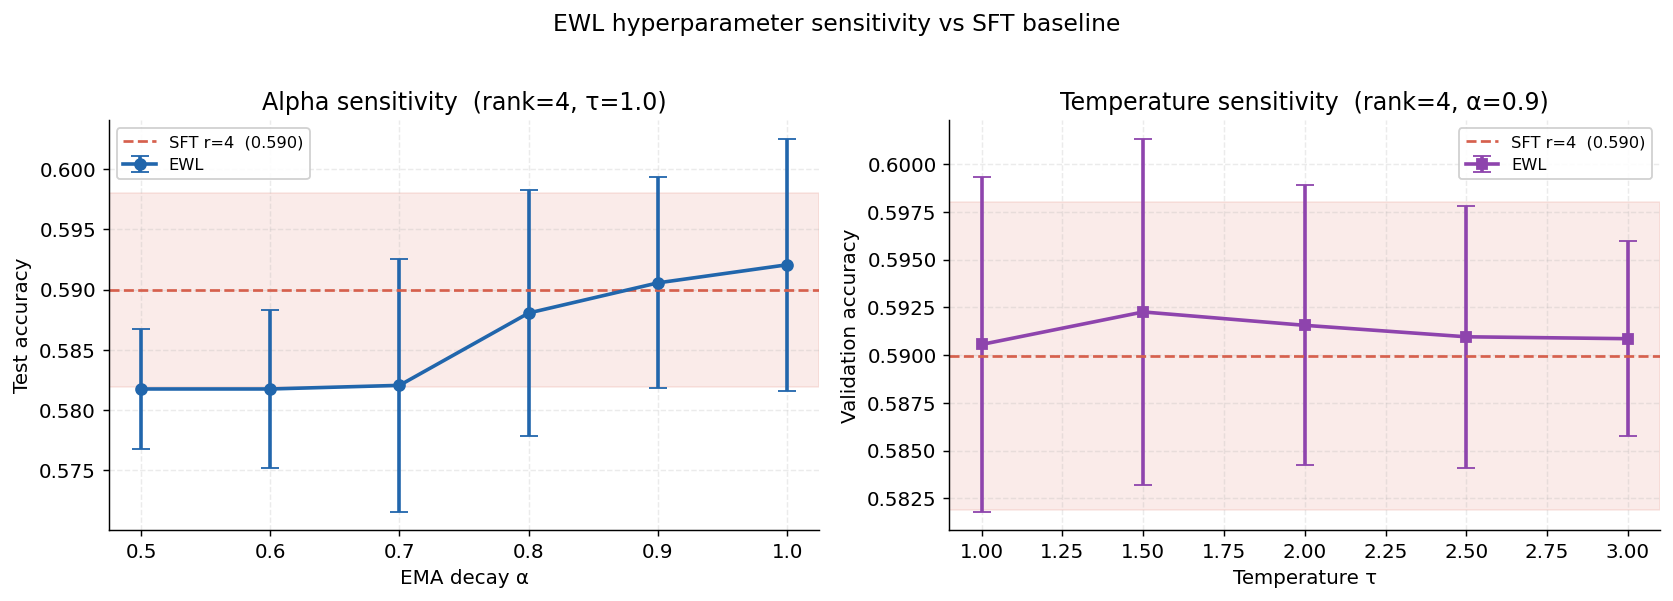

Alpha sensitivity (max−min): 0.0103
Temp  sensitivity (max−min): 0.0017
SFT baseline: 0.5900 ± 0.0081


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: alpha sensitivity at fixed τ=2.0
ys_a_arr = np.array(ys_a)
axes[0].errorbar(ALPHAS, ys_a_arr, yerr=errs_a,
                 fmt="o-", color=C["ewl"], lw=2, capsize=5, label="EWL")
axes[0].axhline(sft_mu, color=C["sft"], lw=1.5, ls="--",
                label=f"SFT r={BEST_RANK}  ({sft_mu:.3f})")
axes[0].axhspan(sft_mu - sft_std, sft_mu + sft_std, color=C["sft"], alpha=0.12)
axes[0].set_xlabel("EMA decay α")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title(f"Alpha sensitivity  (rank={BEST_RANK}, τ={BEST_TEMP})")
axes[0].legend()

# Right: temperature sensitivity at fixed α=0.9
ys_t_arr = np.array(ys_t)
axes[1].errorbar(TEMPS, ys_t_arr, yerr=errs_t,
                 fmt="s-", color="#8E44AD", lw=2, capsize=5, label="EWL")
axes[1].axhline(sft_mu, color=C["sft"], lw=1.5, ls="--",
                label=f"SFT r={BEST_RANK}  ({sft_mu:.3f})")
axes[1].axhspan(sft_mu - sft_std, sft_mu + sft_std, color=C["sft"], alpha=0.12)
axes[1].set_xlabel("Temperature τ")
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title(f"Temperature sensitivity  (rank={BEST_RANK}, α={BEST_ALPHA})")
axes[1].legend()

plt.suptitle("EWL hyperparameter sensitivity vs SFT baseline", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Alpha sensitivity (max−min): {np.nanmax(ys_a_arr) - np.nanmin(ys_a_arr):.4f}")
print(f"Temp  sensitivity (max−min): {np.nanmax(ys_t_arr) - np.nanmin(ys_t_arr):.4f}")
print(f"SFT baseline: {sft_mu:.4f} ± {sft_std:.4f}")

## Summary table
Best EWL configuration vs SFT baseline across all ranks.

In [9]:
rows = []
for r in RANKS:
    ewl_r = df[(df.condition == "ewl") & (df['rank'] == r) &
               (df.alpha == BEST_ALPHA) & (df.temperature == BEST_TEMP)]["test_acc"].dropna()
    sft_r = df[(df.condition == "sft") & (df['rank'] == r)]["test_acc"].dropna()
    if len(ewl_r) == 0 and len(sft_r) == 0:
        continue
    ewl_mu = ewl_r.mean() if len(ewl_r) else float("nan")
    ewl_sd = ewl_r.std()  if len(ewl_r) else float("nan")
    sft_mu_r = sft_r.mean() if len(sft_r) else float("nan")
    sft_sd_r = sft_r.std()  if len(sft_r) else float("nan")
    rows.append({
        "Rank": r,
        "EWL test acc": f"{ewl_mu:.4f} ± {ewl_sd:.4f}" if not np.isnan(ewl_mu) else "—",
        "SFT test acc": f"{sft_mu_r:.4f} ± {sft_sd_r:.4f}" if not np.isnan(sft_mu_r) else "—",
        "Δ (EWL−SFT)":  f"{ewl_mu - sft_mu_r:+.4f}" if not (np.isnan(ewl_mu) or np.isnan(sft_mu_r)) else "—",
        "EWL seeds": len(ewl_r),
        "SFT seeds": len(sft_r),
    })

summary = pd.DataFrame(rows).set_index("Rank")
print(f"Config: α={BEST_ALPHA}, τ={BEST_TEMP}\n")
summary

Config: α=0.9, τ=1.0



,EWL test acc,SFT test acc,Δ (EWL−SFT),EWL seeds,SFT seeds
Rank,,,,,
2,0.5740 ± 0.0023,0.5767 ± 0.0030,-0.0027,3,3
4,0.5906 ± 0.0087,0.5900 ± 0.0081,+0.0006,3,3
8,0.6037 ± 0.0114,0.6056 ± 0.0081,-0.0019,3,3
16,0.6208 ± 0.0101,0.6230 ± 0.0067,-0.0022,3,3


---
## Noise & Imbalance Ablations
Results from `sweep_noise_imbalance.py` — fixed rank=4, α=0.9, τ=2.0, seed=11.
Single seed so no std shading on bars; learning curves are single runs.

In [10]:
# ── Load noise & imbalance results ───────────────────────────────────────────
import re, json, numpy as np, pandas as pd
from pathlib import Path

NI_DIR  = Path("../outputs/vision/aircraft_noise_imbalance")
NI_SEED = 11   # set to None to load all seeds
# ── Fixed hyperparams: read from sweep script (not hardcoded) ───────────────
_sweep_src = (Path("../scripts/sweep_noise_imbalance.py")).read_text()
NI_RANK  = int(re.search(r'^RANK\s*=\s*(\d+)',       _sweep_src, re.M).group(1))
NI_ALPHA = float(re.search(r'^ALPHA\s*=\s*([\d.]+)',  _sweep_src, re.M).group(1))
NI_TEMP  = float(re.search(r'^TEMPERATURE\s*=\s*([\d.]+)', _sweep_src, re.M).group(1))
print(f"NI sweep fixed params: rank={NI_RANK}, alpha={NI_ALPHA}, temperature={NI_TEMP}")


_NOISE_EWL_RE = re.compile(r"^ewl_noise(\d+)pct_s(\d+)$")
_NOISE_SFT_RE = re.compile(r"^sft_noise(\d+)pct_s(\d+)$")
_IMB_EWL_RE   = re.compile(r"^ewl_imb(\d+)_s(\d+)$")
_IMB_SFT_RE   = re.compile(r"^sft_imb(\d+)_s(\d+)$")

def _parse_ni_dir(d):
    n = d.name
    for pattern, cond, sweep in [
        (_NOISE_EWL_RE, "ewl", "noise"),
        (_NOISE_SFT_RE, "sft", "noise"),
        (_IMB_EWL_RE,   "ewl", "imbalance"),
        (_IMB_SFT_RE,   "sft", "imbalance"),
    ]:
        m = pattern.match(n)
        if m:
            return dict(condition=cond, sweep=sweep,
                        value=int(m[1]), seed=int(m[2]))
    return None

def load_ni_runs(base=NI_DIR, seed=NI_SEED):
    """
    Load noise & imbalance runs.
    seed: single int to filter by, or None to load all seeds.
    Always picks the latest results_*.json in each directory.
    """
    rows = []
    for d in sorted(base.iterdir()):
        if not d.is_dir():
            continue
        meta = _parse_ni_dir(d)
        if meta is None:
            continue
        if seed is not None and meta["seed"] != seed:
            continue
        jsons = sorted(d.glob("results_*.json"))
        if not jsons:# or len(jsons) != 3:
            continue
        with open(jsons[-1]) as f:   # latest by timestamp in filename
            payload = json.load(f)
        meta.update({
            "test_acc":  payload.get("test_acc"),
            "test_f1":   payload.get("test_f1"),
            "test_loss": payload.get("test_loss"),
            "history":   payload.get("history", []),
        })
        rows.append(meta)
    df_ni = pd.DataFrame(rows)
    print(f"Loaded {len(df_ni)} NI runs  "
          f"({(df_ni.condition=='ewl').sum()} EWL, {(df_ni.condition=='sft').sum()} SFT)  "
          f"seed={seed}")
    return df_ni

df_ni = load_ni_runs()
df_ni.drop(columns="history").sort_values(["sweep","value","condition"])

NI sweep fixed params: rank=4, alpha=0.9, temperature=1.0


Loaded 20 NI runs  (10 EWL, 10 SFT)  seed=11


,condition,sweep,value,seed,test_acc,test_f1,test_loss
4,ewl,imbalance,5,11,0.233423,0.210806,3.775972
14,sft,imbalance,5,11,0.227123,0.204463,3.695843
1,ewl,imbalance,10,11,0.307231,0.300025,3.050538
11,sft,imbalance,10,11,0.302130,0.292278,2.979554
2,ewl,imbalance,20,11,0.397540,0.395600,2.437108
12,sft,imbalance,20,11,0.396340,0.394504,2.382431
3,ewl,imbalance,50,11,0.510351,0.511440,1.880994
13,sft,imbalance,50,11,0.515152,0.514384,1.824576
0,ewl,imbalance,100,11,0.580558,0.580730,1.560669
10,sft,imbalance,100,11,0.581758,0.581252,1.510318


## Figure 6 — Label noise ablation
Vary noise fraction ∈ {10%, 20%, 30%, 40%} · fixed rank=4, α=0.9, τ=2.0, seed=11.

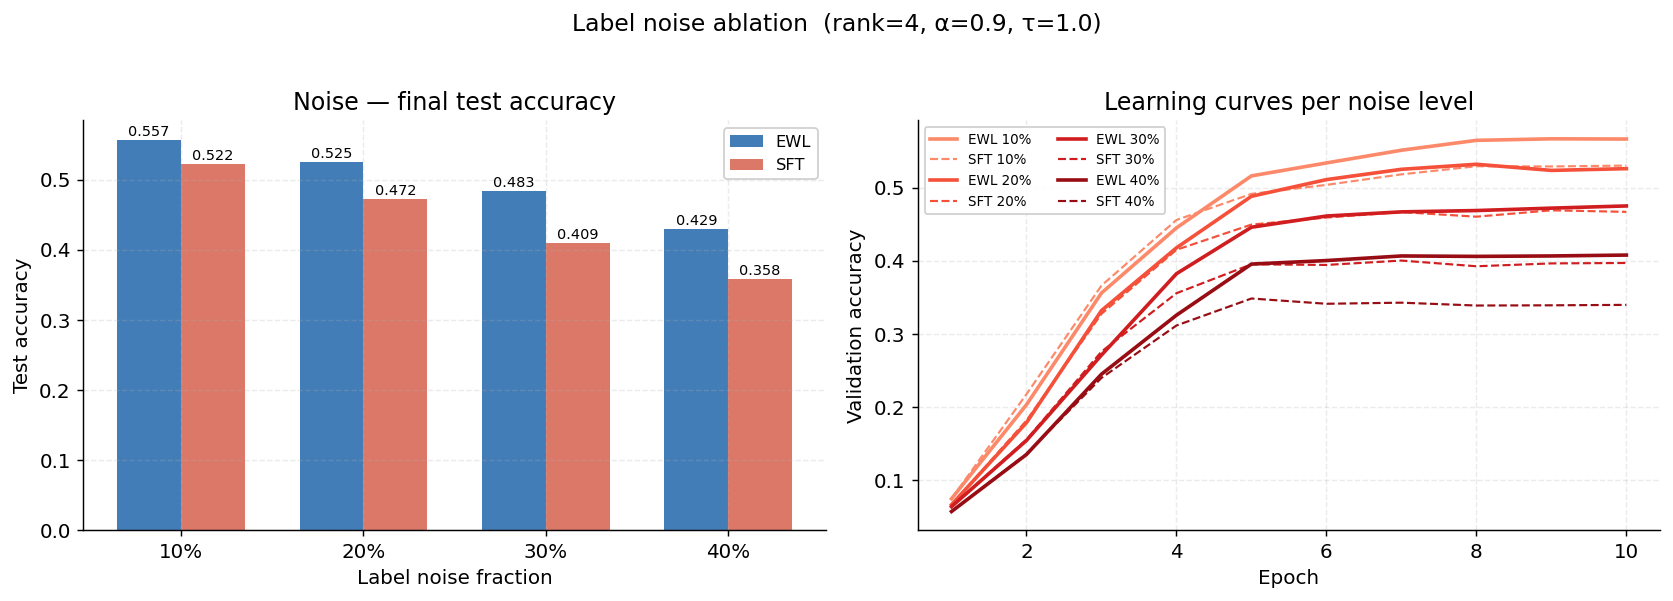

EWL test acc: ['0.5569', '0.5254', '0.4830', '0.4293']
SFT test acc: ['0.5221', '0.4719', '0.4092', '0.3579']
Δ (EWL−SFT): ['+0.0348', '+0.0534', '+0.0738', '+0.0714']


In [11]:
NOISE_LEVELS = [10, 20, 30, 40]   # percent

noise = df_ni[df_ni.sweep == 'noise'].copy()

acc_ewl_n = [noise[(noise.condition=='ewl') & (noise['value']==v)]['test_acc'].values for v in NOISE_LEVELS]
acc_sft_n = [noise[(noise.condition=='sft') & (noise['value']==v)]['test_acc'].values for v in NOISE_LEVELS]

y_ewl_n = [a[0] if len(a) else float('nan') for a in acc_ewl_n]
y_sft_n = [a[0] if len(a) else float('nan') for a in acc_sft_n]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: bar chart
xs = np.arange(len(NOISE_LEVELS))
w = 0.35
bars_e = axes[0].bar(xs - w/2, y_ewl_n, w, color=C['ewl'], alpha=0.85, label='EWL')
bars_s = axes[0].bar(xs + w/2, y_sft_n, w, color=C['sft'], alpha=0.85, label='SFT')
for bar, y in list(zip(bars_e, y_ewl_n)) + list(zip(bars_s, y_sft_n)):
    if not np.isnan(y):
        axes[0].text(bar.get_x() + bar.get_width()/2, y + 0.002,
                     f'{y:.3f}', ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(xs)
axes[0].set_xticklabels([f'{v}%' for v in NOISE_LEVELS])
axes[0].set_xlabel('Label noise fraction')
axes[0].set_ylabel('Test accuracy')
axes[0].set_title('Noise — final test accuracy')
axes[0].legend()

# Right: learning curves (val_acc)
noise_colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(NOISE_LEVELS)))
for v, col in zip(NOISE_LEVELS, noise_colors):
    for cond, ls in [('ewl', '-'), ('sft', '--')]:
        sub = noise[(noise.condition==cond) & (noise['value']==v)]
        ep, mu, _ = get_curves(sub, 'val_acc')
        if len(ep) == 0: continue
        lbl = f'{cond.upper()} {v}%'
        axes[1].plot(ep, mu, color=col, lw=2 if cond=='ewl' else 1.2,
                     ls=ls, label=lbl)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation accuracy')
axes[1].set_title('Learning curves per noise level')
axes[1].legend(fontsize=7.5, ncol=2)

plt.suptitle(f'Label noise ablation  (rank={NI_RANK}, α={NI_ALPHA}, τ={NI_TEMP})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('EWL test acc:', [f'{v:.4f}' for v in y_ewl_n])
print('SFT test acc:', [f'{v:.4f}' for v in y_sft_n])
print('Δ (EWL−SFT):', [f'{e-s:+.4f}' for e, s in zip(y_ewl_n, y_sft_n)])

## Figure 7 — Class imbalance ablation
Vary imbalance factor: code 50→ratio=0.5 (mild), 20→0.2, 10→0.1, 5→0.05 (severe).
Lower ratio = higher class imbalance factor (IF = 1/ratio).

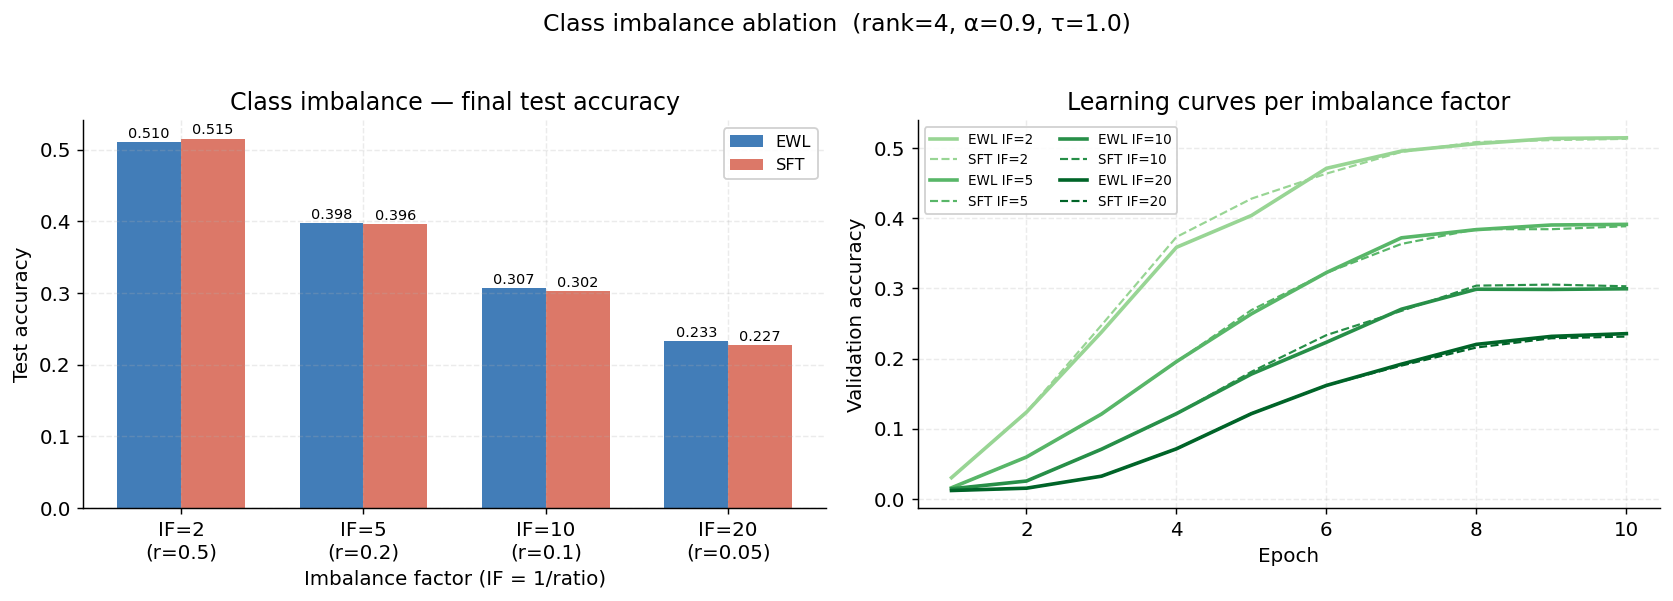

EWL test acc: ['0.5104', '0.3975', '0.3072', '0.2334']
SFT test acc: ['0.5152', '0.3963', '0.3021', '0.2271']
Δ (EWL−SFT): ['-0.0048', '+0.0012', '+0.0051', '+0.0063']


In [12]:
# Sorted from mild to severe: 50 > 20 > 10 > 5
IMB_CODES   = [50, 20, 10, 5]   # as stored in dir name
IMB_RATIOS  = [0.5, 0.2, 0.1, 0.05]  # n_min/n_max
IMB_IF      = [2, 5, 10, 20]          # imbalance factor = 1/ratio

imb = df_ni[df_ni.sweep == 'imbalance'].copy()

acc_ewl_i = [imb[(imb.condition=='ewl') & (imb['value']==v)]['test_acc'].values for v in IMB_CODES]
acc_sft_i = [imb[(imb.condition=='sft') & (imb['value']==v)]['test_acc'].values for v in IMB_CODES]

y_ewl_i = [a[0] if len(a) else float('nan') for a in acc_ewl_i]
y_sft_i = [a[0] if len(a) else float('nan') for a in acc_sft_i]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: bar chart
xs = np.arange(len(IMB_CODES))
bars_e = axes[0].bar(xs - w/2, y_ewl_i, w, color=C['ewl'], alpha=0.85, label='EWL')
bars_s = axes[0].bar(xs + w/2, y_sft_i, w, color=C['sft'], alpha=0.85, label='SFT')
for bar, y in list(zip(bars_e, y_ewl_i)) + list(zip(bars_s, y_sft_i)):
    if not np.isnan(y):
        axes[0].text(bar.get_x() + bar.get_width()/2, y + 0.002,
                     f'{y:.3f}', ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(xs)
axes[0].set_xticklabels([f'IF={f}\n(r={r})' for f, r in zip(IMB_IF, IMB_RATIOS)])
axes[0].set_xlabel('Imbalance factor (IF = 1/ratio)')
axes[0].set_ylabel('Test accuracy')
axes[0].set_title('Class imbalance — final test accuracy')
axes[0].legend()

# Right: learning curves (val_acc)
imb_colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(IMB_CODES)))
for code, if_, col in zip(IMB_CODES, IMB_IF, imb_colors):
    for cond, ls in [('ewl', '-'), ('sft', '--')]:
        sub = imb[(imb.condition==cond) & (imb['value']==code)]
        ep, mu, _ = get_curves(sub, 'val_acc')
        if len(ep) == 0: continue
        lbl = f'{cond.upper()} IF={if_}'
        axes[1].plot(ep, mu, color=col, lw=2 if cond=='ewl' else 1.2,
                     ls=ls, label=lbl)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation accuracy')
axes[1].set_title('Learning curves per imbalance factor')
axes[1].legend(fontsize=7.5, ncol=2)

plt.suptitle(f'Class imbalance ablation  (rank={NI_RANK}, α={NI_ALPHA}, τ={NI_TEMP})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('EWL test acc:', [f'{v:.4f}' for v in y_ewl_i])
print('SFT test acc:', [f'{v:.4f}' for v in y_sft_i])
print('Δ (EWL−SFT):', [f'{e-s:+.4f}' for e, s in zip(y_ewl_i, y_sft_i)])

## Figure 8 — EWL advantage (Δ accuracy) across perturbation levels
Positive = EWL wins, negative = SFT wins.  Note: single seed (11), so treat as exploratory.

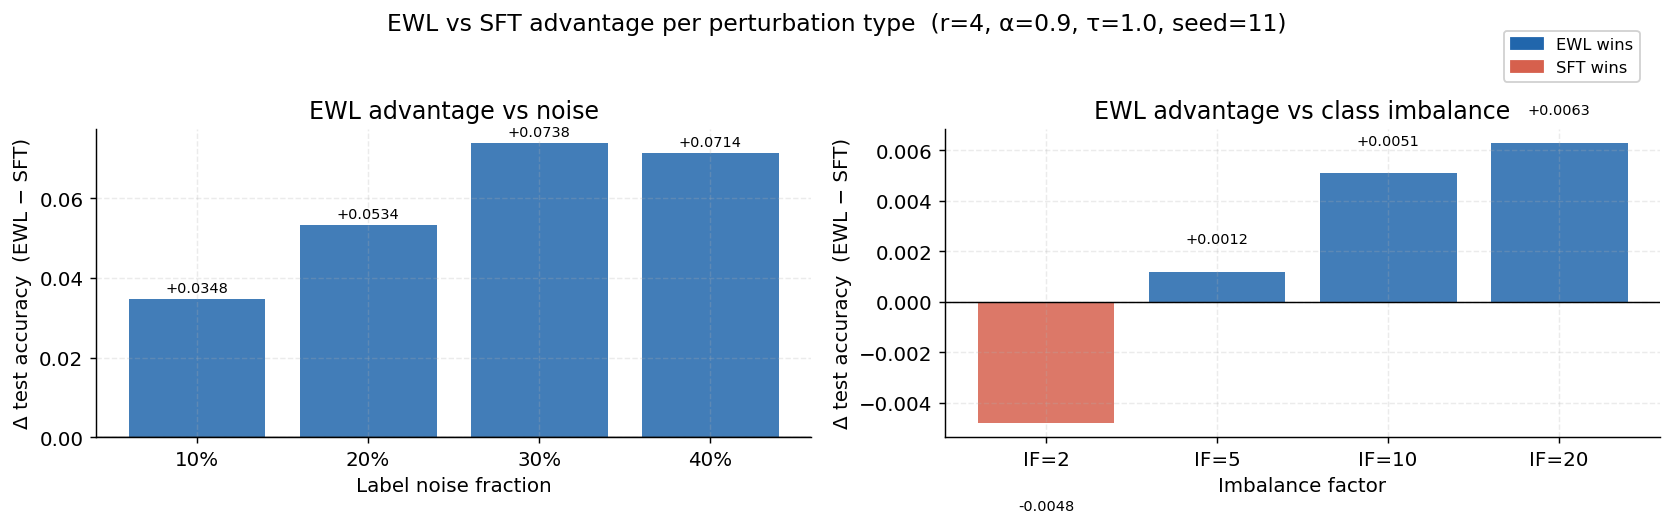

--- Noise sweep ---
  noise 10%: Δ=+0.0348  [EWL]
  noise 20%: Δ=+0.0534  [EWL]
  noise 30%: Δ=+0.0738  [EWL]
  noise 40%: Δ=+0.0714  [EWL]
--- Imbalance sweep ---
  IF= 2:      Δ=-0.0048  [SFT]
  IF= 5:      Δ=+0.0012  [EWL]
  IF=10:      Δ=+0.0051  [EWL]
  IF=20:      Δ=+0.0063  [EWL]


In [13]:
delta_noise = [e - s for e, s in zip(y_ewl_n, y_sft_n)]
delta_imb   = [e - s for e, s in zip(y_ewl_i, y_sft_i)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Noise delta
bar_colors_n = [C['ewl'] if d >= 0 else C['sft'] for d in delta_noise]
axes[0].bar(range(len(NOISE_LEVELS)), delta_noise, color=bar_colors_n, alpha=0.85)
axes[0].axhline(0, color='black', lw=0.8)
for i, d in enumerate(delta_noise):
    axes[0].text(i, d + (0.001 if d >= 0 else -0.003),
                 f'{d:+.4f}', ha='center',
                 va='bottom' if d >= 0 else 'top', fontsize=8)
axes[0].set_xticks(range(len(NOISE_LEVELS)))
axes[0].set_xticklabels([f'{v}%' for v in NOISE_LEVELS])
axes[0].set_xlabel('Label noise fraction')
axes[0].set_ylabel('Δ test accuracy  (EWL − SFT)')
axes[0].set_title('EWL advantage vs noise')

# Imbalance delta
bar_colors_i = [C['ewl'] if d >= 0 else C['sft'] for d in delta_imb]
axes[1].bar(range(len(IMB_IF)), delta_imb, color=bar_colors_i, alpha=0.85)
axes[1].axhline(0, color='black', lw=0.8)
for i, d in enumerate(delta_imb):
    axes[1].text(i, d + (0.001 if d >= 0 else -0.003),
                 f'{d:+.4f}', ha='center',
                 va='bottom' if d >= 0 else 'top', fontsize=8)
axes[1].set_xticks(range(len(IMB_IF)))
axes[1].set_xticklabels([f'IF={f}' for f in IMB_IF])
axes[1].set_xlabel('Imbalance factor')
axes[1].set_ylabel('Δ test accuracy  (EWL − SFT)')
axes[1].set_title('EWL advantage vs class imbalance')

# Shared legend patch
from matplotlib.patches import Patch
legend_el = [Patch(color=C['ewl'], label='EWL wins'), Patch(color=C['sft'], label='SFT wins')]
fig.legend(handles=legend_el, loc='upper right', bbox_to_anchor=(0.98, 1.02))

plt.suptitle(f'EWL vs SFT advantage per perturbation type  (r={NI_RANK}, α={NI_ALPHA}, τ={NI_TEMP}, seed={NI_SEED})', fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

# Quick summary
print('--- Noise sweep ---')
for v, d in zip(NOISE_LEVELS, delta_noise):
    winner = 'EWL' if d > 0 else ('TIE' if d == 0 else 'SFT')
    print(f'  noise {v:2d}%: Δ={d:+.4f}  [{winner}]')
print('--- Imbalance sweep ---')
for if_, d in zip(IMB_IF, delta_imb):
    winner = 'EWL' if d > 0 else ('TIE' if d == 0 else 'SFT')
    print(f'  IF={if_:2d}:      Δ={d:+.4f}  [{winner}]')

## Figure 9 — Rank vs Accuracy: Trend Line
Monotonic improvement with rank — confirms higher capacity helps.

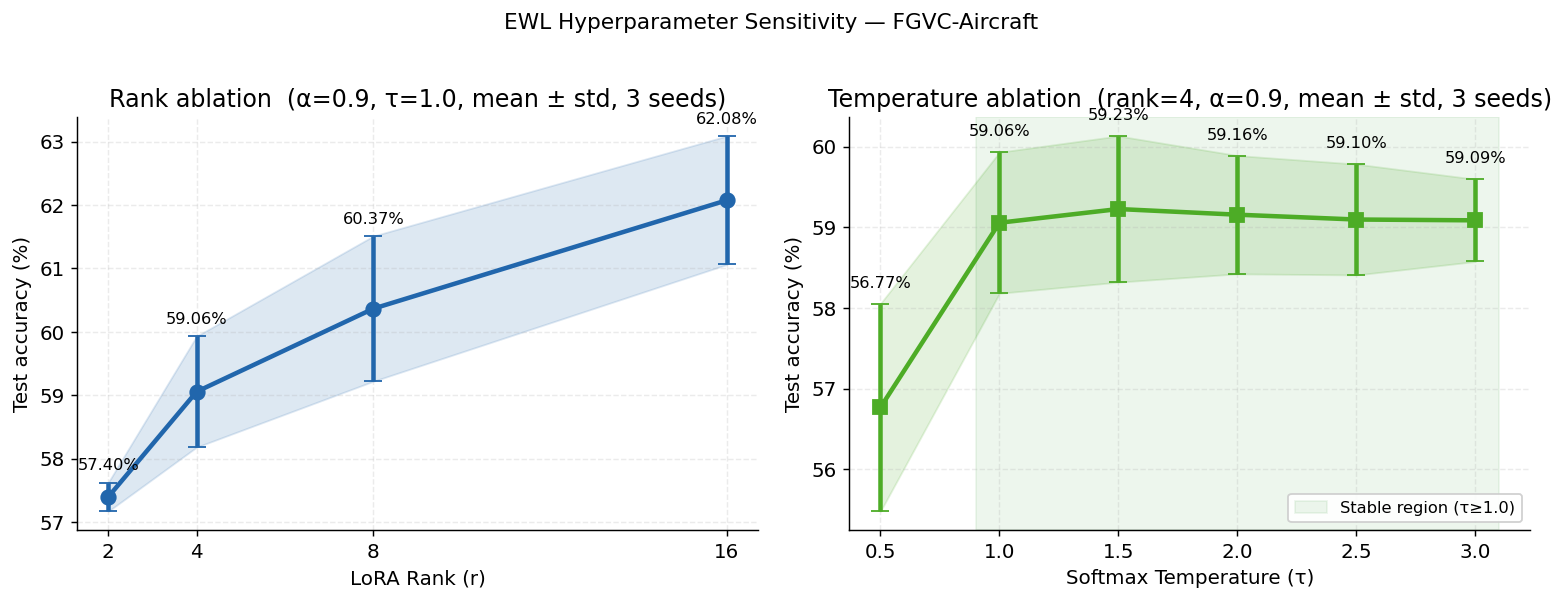

In [14]:
# Re-load results (this cell can run standalone after the main load cell)
import json, glob, re, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

RESULTS_DIR = Path("../outputs/vision/aircraft_ablations")
SEEDS = [11, 22, 33]
_FOLDER_RE = re.compile(r"^r(\d+)_a([0-9.]+)_t([0-9.]+)_s(\d+)$")

rows = []
for d in sorted(RESULTS_DIR.iterdir()):
    if not d.is_dir(): continue
    m = _FOLDER_RE.match(d.name)
    if not m: continue
    rank, alpha, temp, seed = int(m[1]), float(m[2]), float(m[3]), int(m[4])
    if seed not in SEEDS: continue
    jsons = sorted(d.glob("results_*.json"))
    if not jsons: continue
    payload = json.load(open(jsons[-1]))
    rows.append({"rank": rank, "alpha": alpha, "temp": temp, "seed": seed,
                 "test_acc": payload["test_acc"]})

import pandas as pd
df_abl = pd.DataFrame(rows)

# Rank trend
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ranks = sorted(df_abl["rank"].unique())
ys, es = [], []
for r in ranks:
    sub = df_abl[(df_abl["rank"]==r) & (df_abl["alpha"]==0.9) & (df_abl["temp"]==1.0)]["test_acc"]
    ys.append(sub.mean()*100); es.append(sub.std()*100)

ax = axes[0]
ax.errorbar(ranks, ys, yerr=es, fmt="o-", color="#2166AC", lw=2.5, ms=8, capsize=5)
ax.fill_between(ranks, np.array(ys)-np.array(es), np.array(ys)+np.array(es), alpha=0.15, color="#2166AC")
for r, y, e in zip(ranks, ys, es):
    ax.text(r, y + e + 0.2, f"{y:.2f}%", ha="center", fontsize=9)
ax.set_xlabel("LoRA Rank (r)")
ax.set_ylabel("Test accuracy (%)")
ax.set_title("Rank ablation  (α=0.9, τ=1.0, mean ± std, 3 seeds)")
ax.set_xticks(ranks)

# Temperature trend
temps = sorted(df_abl["temp"].unique())
yt, et = [], []
for t in temps:
    sub = df_abl[(df_abl["rank"]==4) & (df_abl["alpha"]==0.9) & (df_abl["temp"]==t)]["test_acc"]
    yt.append(sub.mean()*100); et.append(sub.std()*100)

ax = axes[1]
ax.errorbar(temps, yt, yerr=et, fmt="s-", color="#4DAC26", lw=2.5, ms=8, capsize=5)
ax.fill_between(temps, np.array(yt)-np.array(et), np.array(yt)+np.array(et), alpha=0.15, color="#4DAC26")
for t, y, e in zip(temps, yt, et):
    ax.text(t, y + e + 0.2, f"{y:.2f}%", ha="center", fontsize=9)
ax.set_xlabel("Softmax Temperature (τ)")
ax.set_ylabel("Test accuracy (%)")
ax.set_title("Temperature ablation  (rank=4, α=0.9, mean ± std, 3 seeds)")
ax.set_xticks(temps)
ax.axvspan(0.9, 3.1, alpha=0.07, color="green", label="Stable region (τ≥1.0)")
ax.legend(fontsize=9)

plt.suptitle("EWL Hyperparameter Sensitivity — FGVC-Aircraft", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("fig_rank_temp_trends.pdf", bbox_inches="tight", dpi=1200)
plt.show()


## Figure 10 — Alpha × Temperature Sensitivity Heatmap
Shows that EWL is robust across the full alpha/temp grid (all values ≥1.0).

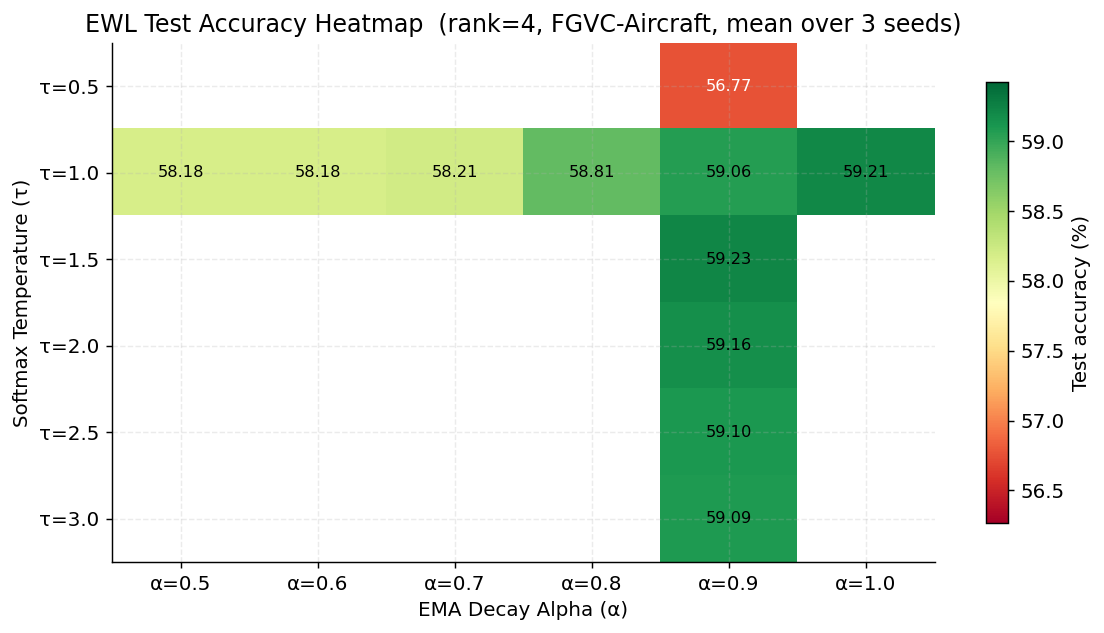

Grid min: 56.77%  max: 59.23%  spread: 2.46%


In [15]:
import numpy as np
import matplotlib.pyplot as plt

alphas_u = sorted(df_abl["alpha"].unique())
temps_u  = sorted(df_abl["temp"].unique())

# Build heatmap matrix: mean test_acc at rank=4
grid = np.zeros((len(temps_u), len(alphas_u)))
for i, t in enumerate(temps_u):
    for j, a in enumerate(alphas_u):
        sub = df_abl[(df_abl["rank"]==4) & (df_abl["alpha"]==a) & (df_abl["temp"]==t)]["test_acc"]
        grid[i, j] = sub.mean()*100 if len(sub) else np.nan

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(grid, aspect="auto", cmap="RdYlGn", vmin=np.nanmin(grid)-0.5, vmax=np.nanmax(grid)+0.2)

ax.set_xticks(range(len(alphas_u)))
ax.set_xticklabels([f"α={a}" for a in alphas_u])
ax.set_yticks(range(len(temps_u)))
ax.set_yticklabels([f"τ={t}" for t in temps_u])
ax.set_xlabel("EMA Decay Alpha (α)")
ax.set_ylabel("Softmax Temperature (τ)")
ax.set_title("EWL Test Accuracy Heatmap  (rank=4, FGVC-Aircraft, mean over 3 seeds)")

# Annotate cells
for i in range(len(temps_u)):
    for j in range(len(alphas_u)):
        v = grid[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                    color="black" if 57 < v < 61 else "white")

plt.colorbar(im, ax=ax, label="Test accuracy (%)", shrink=0.85)
plt.tight_layout()
plt.savefig("fig_alpha_temp_heatmap.pdf", bbox_inches="tight", dpi=1200)
plt.show()

spread = np.nanmax(grid) - np.nanmin(grid)
print(f"Grid min: {np.nanmin(grid):.2f}%  max: {np.nanmax(grid):.2f}%  spread: {spread:.2f}%")


## Figure 11 — Noise + Imbalance Side-by-Side Δ bars
Shows EWL advantage under noise is strong, but imbalance benefit is negligible.

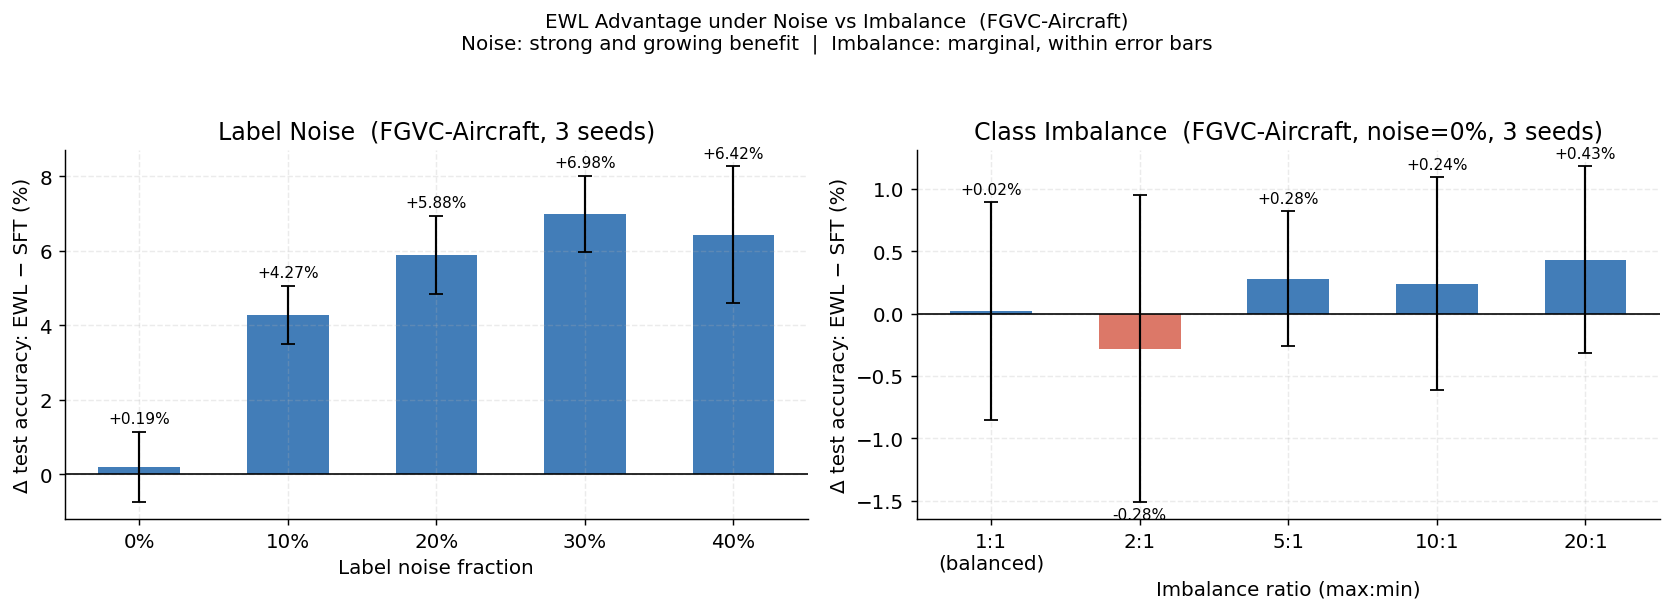

In [16]:
import json, re, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

BASE_NI = Path("../outputs/vision/aircraft_noise_imbalance")
_EWL_N = re.compile(r"^ewl_noise(\d+)pct_s(\d+)$")
_SFT_N = re.compile(r"^sft_noise(\d+)pct_s(\d+)$")
_EWL_I = re.compile(r"^ewl_imb(\d+)_s(\d+)$")
_SFT_I = re.compile(r"^sft_imb(\d+)_s(\d+)$")

noise_data = defaultdict(list)
imb_data   = defaultdict(list)

for d in BASE_NI.iterdir():
    if not d.is_dir(): continue
    jsons = sorted(d.glob("results_*.json"))
    if not jsons: continue
    acc = json.load(open(jsons[-1]))["test_acc"]
    for pattern, store, cond_key in [
        (_EWL_N, noise_data, "ewl"),
        (_SFT_N, noise_data, "sft"),
        (_EWL_I, imb_data,   "ewl"),
        (_SFT_I, imb_data,   "sft"),
    ]:
        m = pattern.match(d.name)
        if m:
            store[(cond_key, int(m[1]))].append(acc)

NOISE_LEVELS = [0, 10, 20, 30, 40]
IMB_CODES    = [100, 50, 20, 10, 5]
IMB_LABELS   = ["1:1\n(balanced)", "2:1", "5:1", "10:1", "20:1"]

def mean_delta(store, cond_a, cond_b, key):
    a = store.get((cond_a, key), [])
    b = store.get((cond_b, key), [])
    if a and b:
        return (np.mean(a) - np.mean(b)) * 100, np.sqrt(np.std(a)**2 + np.std(b)**2) * 100
    return np.nan, 0

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Noise deltas
ax = axes[0]
d_n = [mean_delta(noise_data, "ewl", "sft", v) for v in NOISE_LEVELS]
dn, en = zip(*d_n)
colors_n = ["#2166AC" if d >= 0 else "#D6604D" for d in dn]
xs = np.arange(len(NOISE_LEVELS))
bars = ax.bar(xs, dn, color=colors_n, alpha=0.85, width=0.55)
ax.errorbar(xs, dn, yerr=en, fmt="none", color="black", capsize=4, lw=1.2)
ax.axhline(0, color="black", lw=0.9)
for bar, d, e in zip(bars, dn, en):
    if not np.isnan(d):
        va = "bottom" if d >= 0 else "top"
        ax.text(bar.get_x()+bar.get_width()/2, d+(e+0.15 if d>=0 else -(e+0.15)),
                f"{d:+.2f}%", ha="center", va=va, fontsize=8.5)
ax.set_xticks(xs); ax.set_xticklabels([f"{v}%" for v in NOISE_LEVELS])
ax.set_xlabel("Label noise fraction")
ax.set_ylabel("Δ test accuracy: EWL − SFT (%)")
ax.set_title("Label Noise  (FGVC-Aircraft, 3 seeds)")

# Imbalance deltas
ax = axes[1]
d_i = [mean_delta(imb_data, "ewl", "sft", v) for v in IMB_CODES]
di, ei = zip(*d_i)
colors_i = ["#2166AC" if d >= 0 else "#D6604D" for d in di]
bars = ax.bar(xs, di, color=colors_i, alpha=0.85, width=0.55)
ax.errorbar(xs, di, yerr=ei, fmt="none", color="black", capsize=4, lw=1.2)
ax.axhline(0, color="black", lw=0.9)
for bar, d, e in zip(bars, di, ei):
    if not np.isnan(d):
        va = "bottom" if d >= 0 else "top"
        ax.text(bar.get_x()+bar.get_width()/2, d+(e+0.04 if d>=0 else -(e+0.04)),
                f"{d:+.2f}%", ha="center", va=va, fontsize=8.5)
ax.set_xticks(xs); ax.set_xticklabels(IMB_LABELS)
ax.set_xlabel("Imbalance ratio (max:min)")
ax.set_ylabel("Δ test accuracy: EWL − SFT (%)")
ax.set_title("Class Imbalance  (FGVC-Aircraft, noise=0%, 3 seeds)")

plt.suptitle("EWL Advantage under Noise vs Imbalance  (FGVC-Aircraft)\n"
             "Noise: strong and growing benefit  |  Imbalance: marginal, within error bars",
             fontsize=11, y=1.04)
plt.tight_layout()
plt.savefig("fig_noise_imbalance_delta.pdf", bbox_inches="tight", dpi=1200)
plt.show()
